In [1]:
# !pip install numpy
# !pip install pandas
# !pip install matplotlib
# !pip install seaborn
import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns

pd.set_option('display.max_columns', 50)

**Discussion:**

Nominal variables: Age, Job, Marital (status), Contact (telephone vs. cell), poutcome (outcome of previous marketing campaign), y (term 
                   deposit; binary response), Default (credit), Housing (loan), Loan (personal)
                   
Ordinal variables: Education

Interval variables: Day_of_week, Month, pdays (# days passed since client was last contacted --> interval b/c can be -1), emp.var.rate, 
                    cons.conf.idx, cons.price.idx
                    
Ratio variables: Balance (average yearly in euros), Duration (last contact duration), Campaign (# contacts for this campaign and client), 
                 previous (# contacts before this campaign), eurobor3m, nr.employed (# employees)


It is clear from both the data dictionary as well as the actual data that the set is incomplete. It seems those five variables were added to show us the importance of some of the data and how to interpret both unknown and incomplete values. However, even some of the original variables — communication type, pdays and poutcome all have missing values, which may much more uncertainty but can be thought about for reasoning.

Perhaps some were contacted by word of mouth and this was not one of the applicable options. I can't think of a good reason why the pdays variable would have blanks, but perhaps for poutcome, if the previous marketing campaign was never resolved, then maybe it wasn't even indiciated as a failure.

### **Load the Dataset**

In [2]:
#!pip install openpyxl
bank = pd.read_excel('bank-additional-full.xlsx')


In [8]:
bank.head().T # transpose the data 

,0,1,2,3,4
IDX,1,2,3,4,5
age,56,57,37,40,56
job,housemaid,services,services,admin.,services
marital,married,married,married,married,married
education,basic.4y,high.school,high.school,basic.6y,high.school
default,no,unknown,no,no,no
housing,no,no,yes,no,no
loan,no,no,no,no,yes
contact,telephone,telephone,telephone,telephone,telephone
month,may,may,may,may,may


In [3]:
bank.describe()

,IDX,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,20594.50000,40.030761,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,11890.09578,10.512520,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,1.00000,5.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,10297.75000,32.000000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,20594.50000,38.000000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,30891.25000,47.000000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,41188.00000,311.000000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [4]:
bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   IDX             41188 non-null  int64  
 1   age             41188 non-null  int64  
 2   job             41188 non-null  object 
 3   marital         41187 non-null  object 
 4   education       41188 non-null  object 
 5   default         41187 non-null  object 
 6   housing         41188 non-null  object 
 7   loan            41188 non-null  object 
 8   contact         41188 non-null  object 
 9   month           41187 non-null  object 
 10  day_of_week     41188 non-null  object 
 11  duration        41188 non-null  int64  
 12  campaign        41188 non-null  int64  
 13  pdays           41188 non-null  int64  
 14  previous        41188 non-null  int64  
 15  poutcome        41187 non-null  object 
 16  emp.var.rate    41188 non-null  float64
 17  cons.price.idx  41188 non-null 

**Discussion:**

I think one important point that I can see is missing is the year is not represented — if someone were to sort by month, all the "May" values would be arranged together and the user would then assume all these values were from the same year.

Personally, some important predictors of y, without performing an in-depth data analysis, include job and marital status because those could both determine if and when someone has the funds to invest money (and jointly with spouses). Average yearly balance obviously is probably the biggest predictor, but also if there is a default credit balance and if the person has taken a personal loan.

Other important predictors for y include the number of contacts in this campaign and those that have been performed before and for this particular client.

***
## Provide basic statistics for the attributes
***

In [5]:
summary_quant_data = (
    bank.groupby("y")[  # replace "y" with your grouping column
        ['age', 'duration', 'pdays', 'previous', 
         'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 
         'euribor3m', 'nr.employed']
    ].median()
)

summary_quant_data

,age,duration,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
y,,,,,,,,,
no,38.0,163.0,999.0,0.0,1.1,93.918,-41.8,4.857,5195.8
yes,37.0,449.0,999.0,0.0,-1.8,93.200,-40.4,1.266,5099.1


In [6]:
bank.describe()

,IDX,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,20594.50000,40.030761,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,11890.09578,10.512520,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,1.00000,5.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,10297.75000,32.000000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,20594.50000,38.000000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,30891.25000,47.000000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,41188.00000,311.000000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [7]:
bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   IDX             41188 non-null  int64  
 1   age             41188 non-null  int64  
 2   job             41188 non-null  object 
 3   marital         41187 non-null  object 
 4   education       41188 non-null  object 
 5   default         41187 non-null  object 
 6   housing         41188 non-null  object 
 7   loan            41188 non-null  object 
 8   contact         41188 non-null  object 
 9   month           41187 non-null  object 
 10  day_of_week     41188 non-null  object 
 11  duration        41188 non-null  int64  
 12  campaign        41188 non-null  int64  
 13  pdays           41188 non-null  int64  
 14  previous        41188 non-null  int64  
 15  poutcome        41187 non-null  object 
 16  emp.var.rate    41188 non-null  float64
 17  cons.price.idx  41188 non-null 

In [9]:
bank['job'].value_counts() # job counts

job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

In [11]:
bank['marital'].value_counts() # marital status counts

marital
married     24927
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64

In [12]:
bank['education'].value_counts() # education level counts

education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64

In [13]:
bank['default'].value_counts() # binary default credit counts

default
no         32587
unknown     8597
yes            3
Name: count, dtype: int64

In [14]:
bank['housing'].value_counts() # number of clients with a housing loan

housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64

In [15]:
bank['loan'].value_counts() # number of clients with a personal loan

loan
no         33950
yes         6248
unknown      990
Name: count, dtype: int64

In [16]:
bank['contact'] = bank['contact'].replace('telephonee', 'telephone') # one misspelled value of "telephone"
bank['contact'].value_counts() # number of each marketing method of contact

contact
cellular     26144
telephone    15044
Name: count, dtype: int64

In [17]:
bank['month'].value_counts() # number of last outreaches in each month
# problem described above --> substantially more values for May because listed twice

month
may    13769
jul     7174
aug     6178
jun     5317
nov     4101
apr     2632
oct      718
sep      570
mar      546
dec      182
Name: count, dtype: int64

In [18]:
bank['day_of_week'] = bank['day_of_week'].replace('fr', 'fri') # one different abbreviation of Friday
bank['day_of_week'].value_counts() # number of last outreaches on each day

day_of_week
thu    8623
mon    8514
wed    8134
tue    8090
fri    7827
Name: count, dtype: int64

In [19]:
bank['poutcome'].value_counts() # number of outcomes of previous marketing campaigns

poutcome
nonexistent    35562
failure         4252
success         1373
Name: count, dtype: int64

In [20]:
bank['y'].value_counts() # number of term deposit subscriptions (time deposits)

y
no     36547
yes     4640
Name: count, dtype: int64

**Discussion:**

Doing a slightly deeper dive — i.e. looking at the most basic summary statistics — we see that the average age for a client was roughly 40 years old. However, here we see an outlier which is probabbly a mistake in the input of data: there is no way anyone is 311 years old, which seems like a human input error because there is only value of this value. The 112 age seems very much an outlier as well, but at least still a possible value.

The average duration of the last call to the client was roughly 4 minutes, 20 seconds long. The number of campaigns performed for a single client during a single campaign on average was a little less than 3 — it doesn't seem plausible, unless it was someone extremely famous that 56 methods of contact would be performed in a single campaign, but this is not really even an outlier given other data. The average number of previous campaigns for a single client was roughly less than 1, meaning more clients were not marketed to than were.

Average number of days that passed between contacts was 962. The employee variation rate was roughly 0.08 — this is good because this means there is low employee turnover.

The consumer indices can go into the negatives, meaning those metrics are bad for business likely — the price index is fine, but the confidence index is much lower than where we want it to be. Considering the max does not eclipse even zero, there is something that we need to do better in marketing or in our product as a whole.

European banks on average will lend each other money at a 3.6% interest rate, and at most 5%. That value relatively should be high considering it's coming from banks.

The number of employed individuals at most was 5,228 but on average stayed in the mid-5,100 range.

In terms of jobs, administrators and blue-collar workers led the way. Most clients were married and had some sort of university degree.

Most people did not have default credit. Most people took housing loans but not personal loans.

It makes sense that most people were contacted by cellphone rather than landline/telephone.

We need to perform more analyses for success rate correlating to day and month, but it seemed most campaigns were marketed on Thursdays or Mondays in May.

Many marketing campaigns didn't have an outcome at all — for a bank, this should be viewed as a failure unless those campaigns are still ongoing. It also makes sense that there were more failures than successes with those campaigns. On the same note, there were about 9x less time deposits than the opposite.

***
## Visualizations
***

**Discussion:**

My approach here was to make a new dataset without the missing values from the original dataset. I then want to make pie charts for marital status, job and education in relation to the clients, and then make another for most "successful" marketing month.

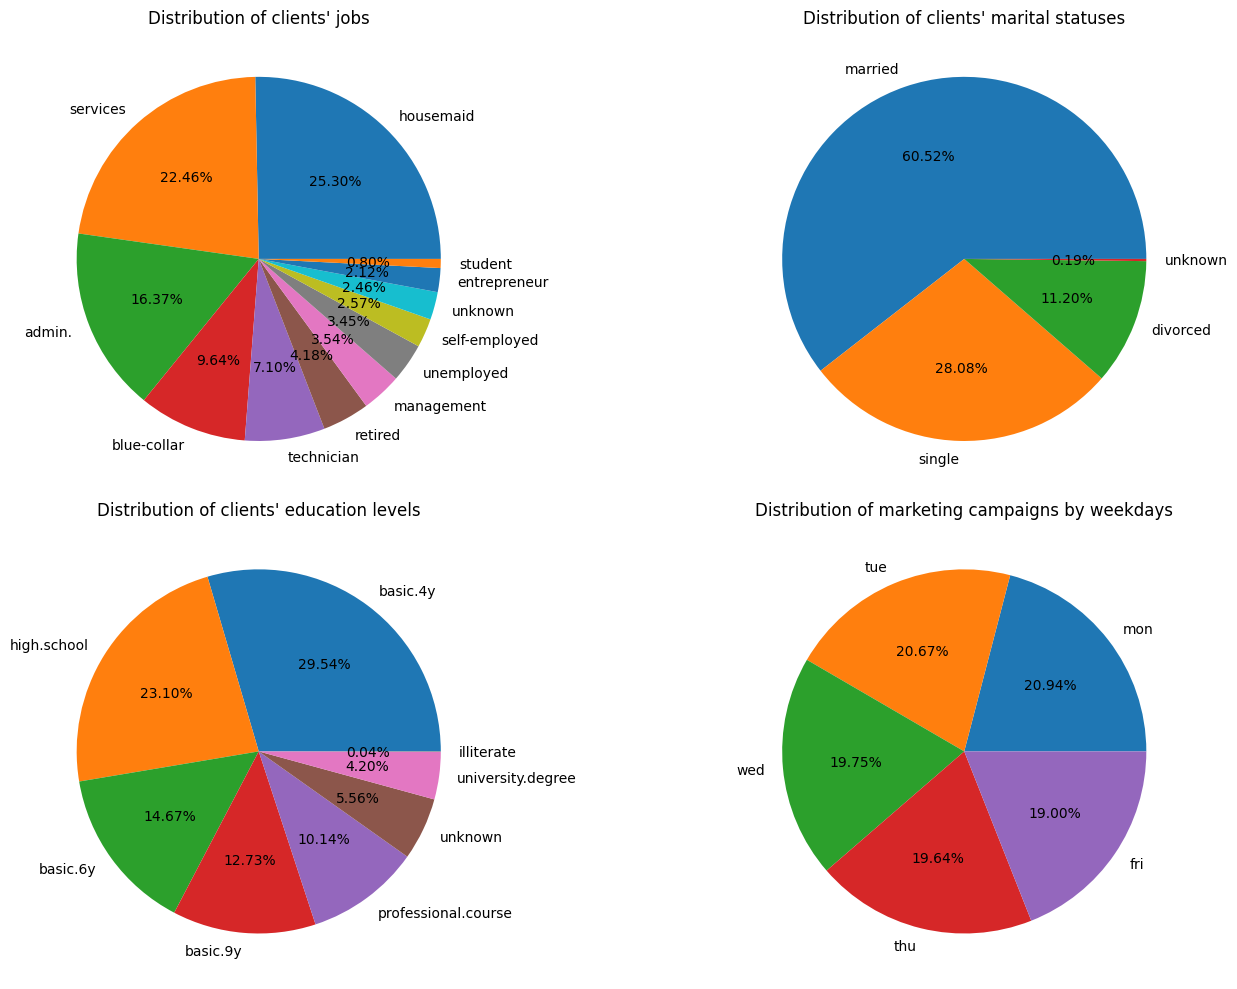

In [21]:
sub_bank = bank
sub_bank = sub_bank.dropna()

# Create 2x2 data matrix
fig, axs = plt.subplots(2, 2, figsize=(15, 10))

# Job pie chart

job_cat = sub_bank['job'].unique()
job_val = sub_bank['job'].value_counts()

axs[0,0].pie(job_val, labels=job_cat, autopct='%1.2f%%')
axs[0,0].set_title('Distribution of clients\' jobs')


# Marital status

mar_cat = sub_bank['marital'].unique()
mar_val = sub_bank['marital'].value_counts()

axs[0, 1].pie(mar_val, labels=mar_cat, autopct='%1.2f%%')
axs[0, 1].set_title('Distribution of clients\' marital statuses')


# Education

edu_cat = sub_bank['education'].unique()
edu_val = sub_bank['education'].value_counts()

axs[1, 0].pie(edu_val, labels=edu_cat, autopct='%1.2f%%')
axs[1, 0].set_title('Distribution of clients\' education levels')


# General most successful day of week

day_cat = sub_bank['day_of_week'].unique()
day_val = sub_bank['day_of_week'].value_counts()

axs[1,1].pie(day_val, labels=day_cat, autopct='%1.2f%%')
axs[1,1].set_title('Distribution of marketing campaigns by weekdays')


# Adjust layout for better display
plt.tight_layout()

# Show the plots
plt.show()

**Discussion:**

We first cleaned the data slightly so we were able to negate missing data points.

In the first case with jobs, the clients who were mainly contacted were in the services industry, or were housemaids or administrators. It was rare that students and entrepreneurs were contacted.

In terms of clients' marital statuses, over 60% were married, while just under 30% were single and the mostly remaining 11% were previously married.

Most clients contacted had attended a basic four-year college, but only 4% of all had a university degree. Twenty-three percent of those contacted had a high school diploma. Less than 0.05% of clients contacted were illiterate — perhaps those constitute the very young population (there was one 5 year old, but how can we determine who is making up the other part of the percentage?).

Finally, in terms of weekdays, let's say that the bank found out that one day in particular generated the most success and/or we had the most time that day. That most successful and perhaps most time-consuming day would have been Monday, followed by Tuesday. Throughout the week, it is obvious either we were having less success or we were getting decreasingly motivated to fulfill our jobs because the distribution of campaigns lessened as the week went on.

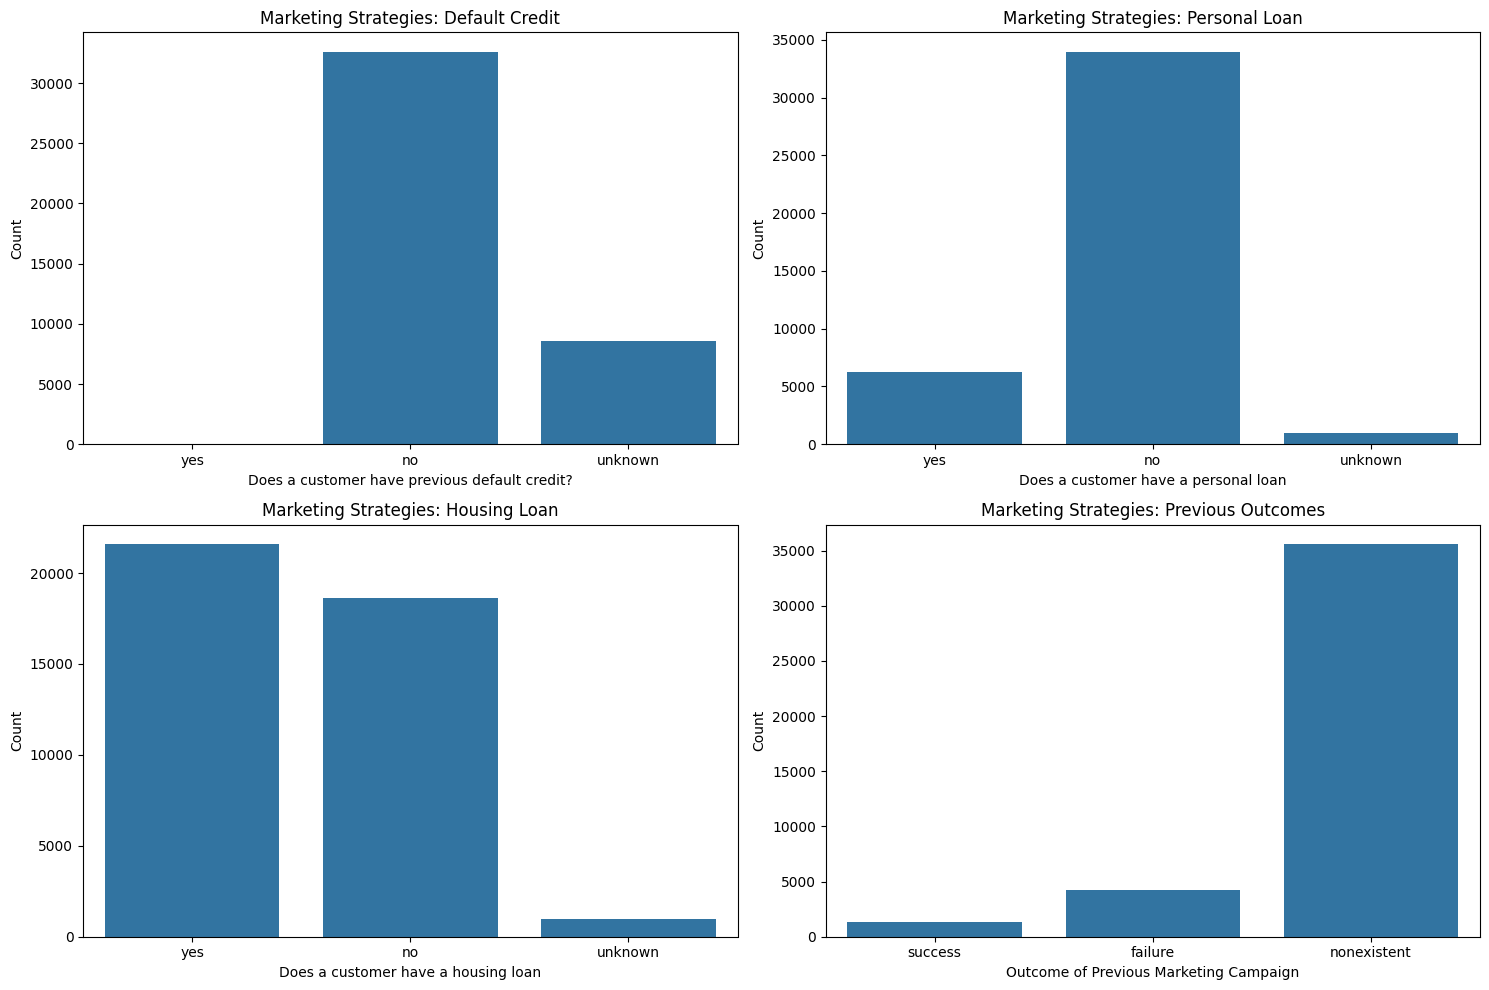

In [22]:
sub_bank = bank
sub_bank = sub_bank.dropna()

# Create 2x2 data matrix
fig, axs = plt.subplots(2, 2, figsize=(15, 10))

# Default Credit Bar Chart

sns.countplot(x="default", data=sub_bank, order=["yes", "no", "unknown"], ax=axs[0, 0])
axs[0, 0].set_title("Marketing Strategies: Default Credit")
axs[0, 0].set_xlabel("Does a customer have previous default credit?")
axs[0, 0].set_ylabel("Count")


# Housing loan

sns.countplot(x="housing", data=sub_bank, order=["yes", "no", "unknown"], ax=axs[1, 0])
axs[1, 0].set_title("Marketing Strategies: Housing Loan")
axs[1, 0].set_xlabel("Does a customer have a housing loan")
axs[1, 0].set_ylabel("Count")


# Personal loan

sns.countplot(x="loan", data=sub_bank, order=["yes", "no", "unknown"], ax=axs[0, 1])
axs[0, 1].set_title("Marketing Strategies: Personal Loan")
axs[0, 1].set_xlabel("Does a customer have a personal loan")
axs[0, 1].set_ylabel("Count")


# Previous Outcomes

sns.countplot(x='poutcome', data=sub_bank, order = ["success", "failure", "nonexistent"], ax=axs[1,1])
axs[1,1].set_title("Marketing Strategies: Previous Outcomes")
axs[1,1].set_xlabel("Outcome of Previous Marketing Campaign")
axs[1,1].set_ylabel("Count")


# Adjust layout for better display
plt.tight_layout()

# Show the plots
plt.show()

**Discussion:**

With respect to some of our actual marketing strategies — I apologize because I was unable to put these into pairwise plots like the ones below — it was rare that any customers had a default credit in their bank account. It was also rare that a customer had taken out a personal loan, but was seemed very common that they would take out housing loans.

Most clients were contacted via cell, while others were contacted via telephone.

Altogether, there was a very low number of successful campaigns, while there weren't many more failures (relatively). There was a large number of nonexistent campaigns, however, telling us that either these campaigns were never even started with the customer or they were never finished and are still ongoing.

***
## Data quality Issues
***

**Discussion:**

For the sake of redundancy, I won't explain the 311 year old in age again, nor some of the blanks which have already been explained earlier.

In the previous sections with my graphs, I dropped all the missing values from the dataset, certainly honing in on values that existed. This allowed me to perform a preliminary EDA with the graphs I was able to produce.

I also explained the discrepancy with the months and why May had the outstanding most data points.

It is difficult to say whether there are any real outliers with the data in duration of campaign because those span from 0 seconds to more than 4000 seconds.

Although the data dictionary says there's no blanks in the marital column, there is 1 — we can likely drop this value since it's not going to skew the data any way. We can do the same with the lone blank in the default credit column, as well as the lone blank in the month and poutcome columns. Finally, we can do the same with the lone blank in the target response column.

As we can see with the code block below, no duplicates exist.

In [23]:
duplicates = bank[bank.duplicated()]
duplicates # no duplicates exist

,IDX,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y


**Discussion:**

For checking the missing values, there wasn't a whole lot needed to be done besides dropping the missing rows, which I explained above. I used that method to produce the plots above and below as well so that missing values — or "nan's" — would not appear.

You can see below that there weren't that many missing values. If you compare the number of tuples present for the original dataset, which I called "bank," and the one without missing values — "sub_bank" — there are roughly five less rows.

**Discussion:**

We will now attempt to find outliers, which we can do by making boxplots for the quantitative variables.

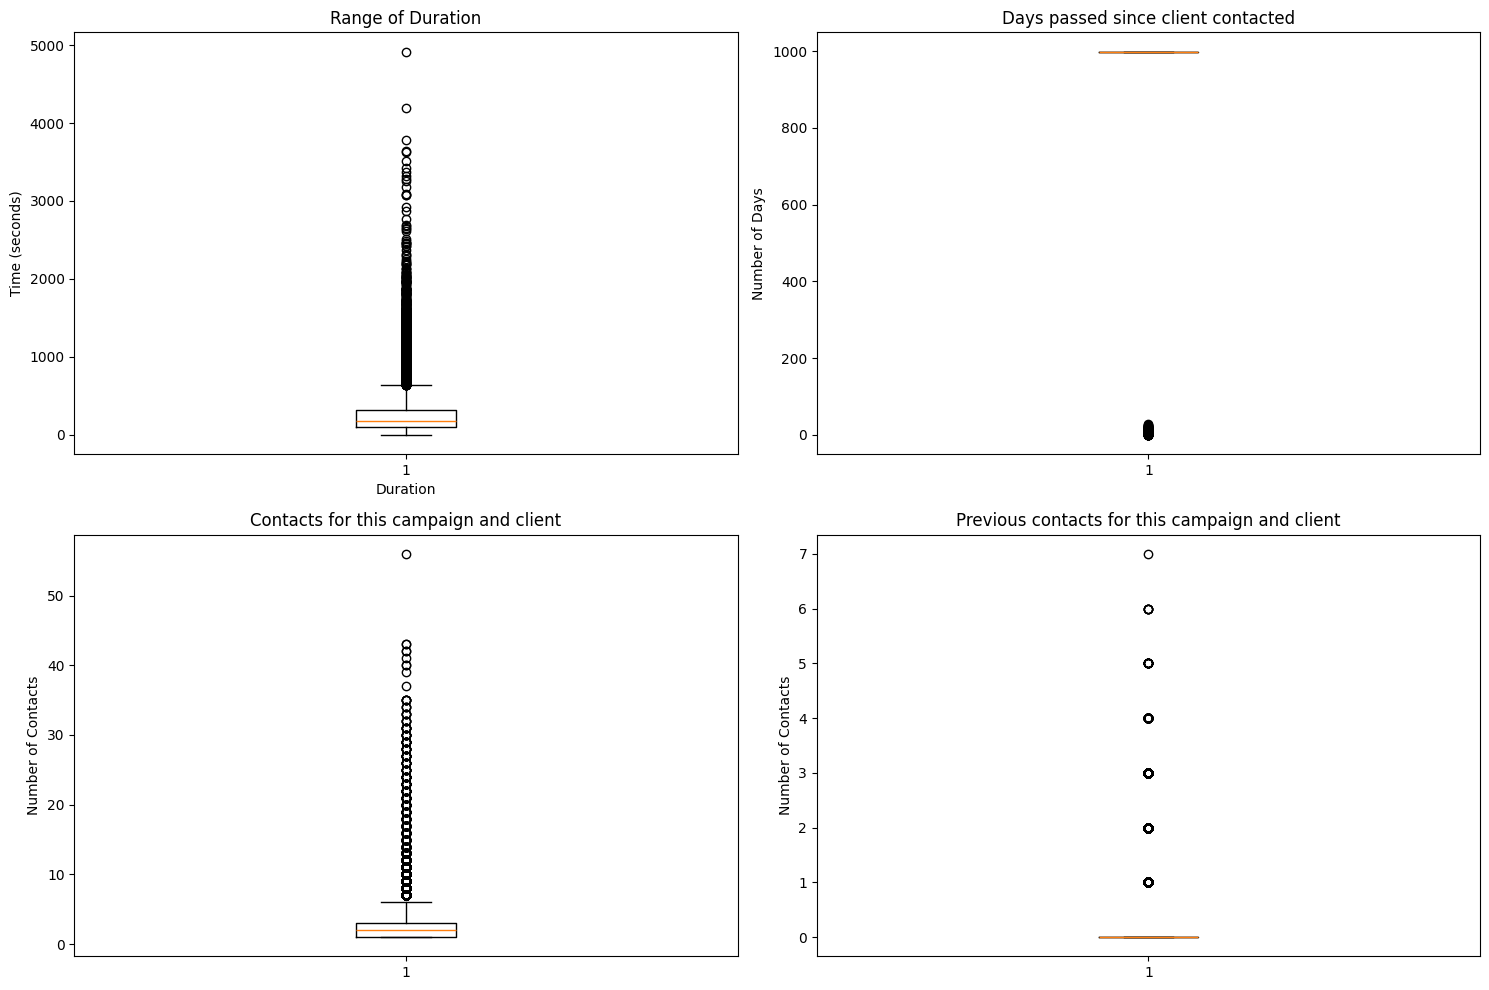

In [24]:
import matplotlib.pyplot as plt

# Create 2x2 data matrix
fig, axs = plt.subplots(2, 2, figsize=(15, 10))

# Boxplot for time duration of the last contact of a client
axs[0,0].boxplot(sub_bank['duration'])
axs[0,0].set_title('Range of Duration')
axs[0,0].set_xlabel('Duration')
axs[0,0].set_ylabel('Time (seconds)')

# Contacts for contemporary campaign and client
axs[1,0].boxplot(sub_bank['campaign'])
axs[1,0].set_title('Contacts for this campaign and client')
axs[1,0].set_ylabel('Number of Contacts')

# Days passed since client contacted
axs[0,1].boxplot(sub_bank['pdays'])
axs[0,1].set_title('Days passed since client contacted')
axs[0,1].set_ylabel('Number of Days')

# Previous contacts for this campaign and client
axs[1,1].boxplot(sub_bank['previous'])
axs[1,1].set_title('Previous contacts for this campaign and client')
axs[1,1].set_ylabel('Number of Contacts')

# Adjust layout for better display
plt.tight_layout()

# Show the plots
plt.show()

**Discussion:**

With the plots above, there are clearly many outliers for each data attribute. The range of duration spans from [0, 4918], so this makes sense but it's clear the median is much closer to 100-200. Perhaps approaching an analyses with a weighted mean would be a good way to go. The mean of the data is just under 260 seconds.

Roughly the same comes from the number of contacts for this campaign and client, although clearly less number of outliers. The biggest outlier is 56 contacts, where a client was contacted 56 times, 13 more than any other client.

For the previous number of contacts, there is a small count of discrete data points, which doesn't make a whole lot of sense for a boxplot. The box and whiskers are all centered around zero, while the "outliers" represent just any other data point.

Finally, since the number of days since the client was last contacted skews so much toward the higher data points, the outliers represent the values closer to 0, which is not a lot of the data.

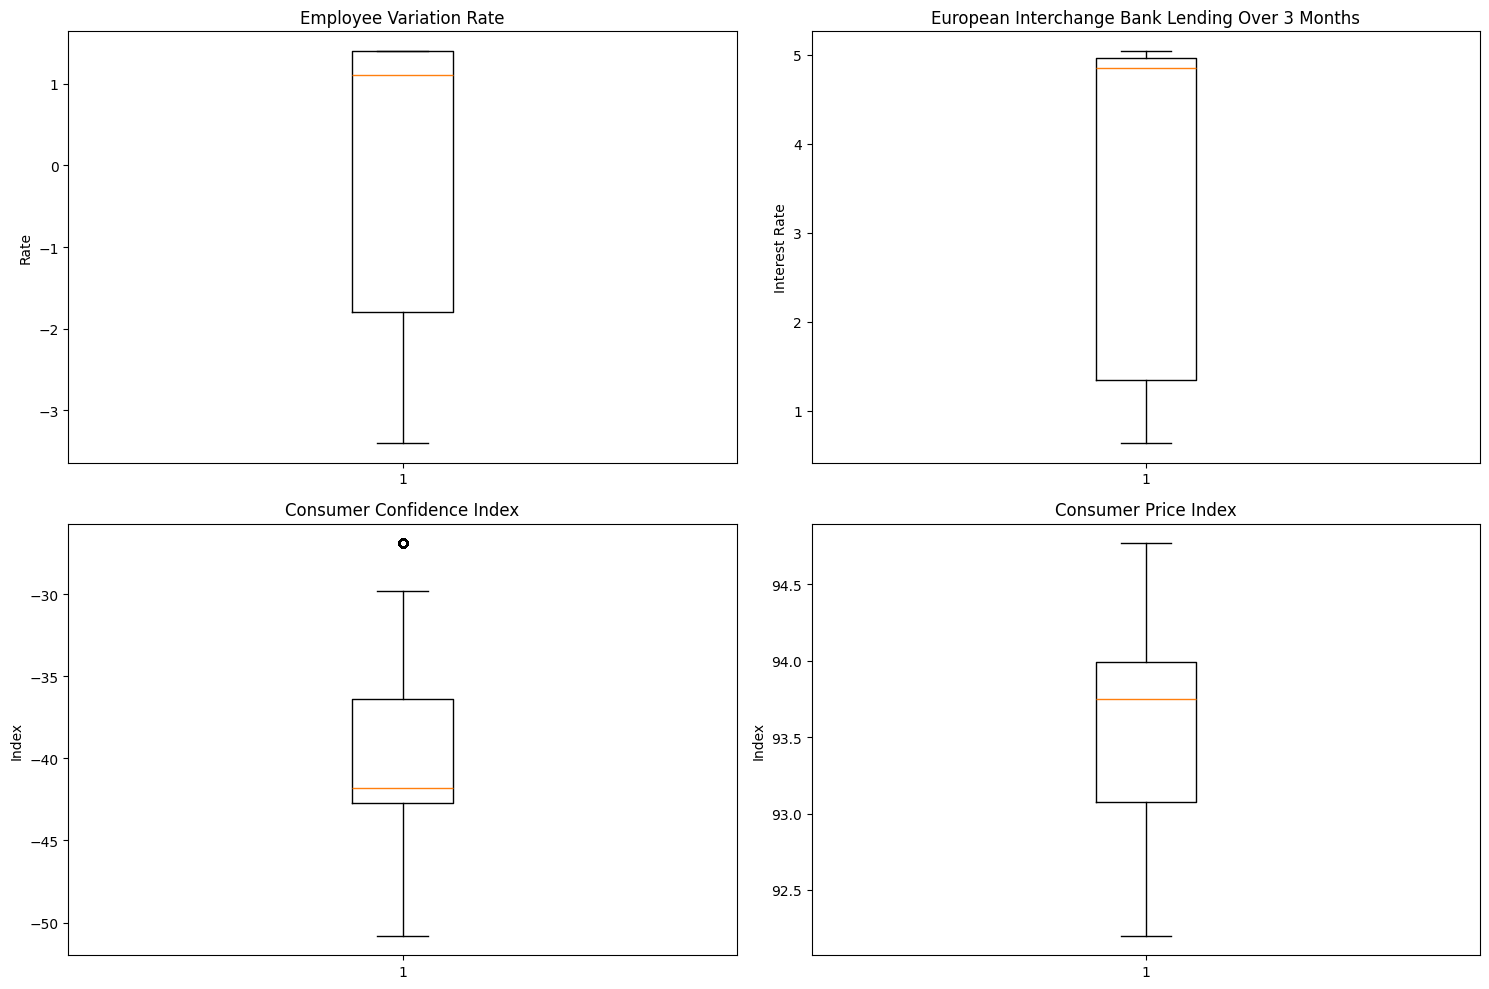

np.float64(0.08180317121142214)

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Create 2x2 data matrix
fig, axs = plt.subplots(2, 2, figsize=(15, 10))

# Employee Variation rate
axs[0,0].boxplot(sub_bank['emp.var.rate'])
axs[0,0].set_title('Employee Variation Rate')
axs[0,0].set_ylabel('Rate')

# European Interchange Bank Lending Over 3 months
axs[0,1].boxplot(sub_bank['euribor3m'])
axs[0,1].set_title('European Interchange Bank Lending Over 3 Months')
axs[0,1].set_ylabel('Interest Rate')

# Consumer Confidence Index
axs[1,0].boxplot(sub_bank['cons.conf.idx'])
axs[1,0].set_title('Consumer Confidence Index')
axs[1,0].set_ylabel('Index')

# Consumer Price Index
axs[1,1].boxplot(sub_bank['cons.price.idx'])
axs[1,1].set_title('Consumer Price Index')
axs[1,1].set_ylabel('Index')

# Adjust layout for better display
plt.tight_layout()

# Show the plots
plt.show()

sub_bank['emp.var.rate'].mean()

**Discussion:**

The rates and indices do a much better job of nullifying outliers in the dataset.

There is only a single outlier, given by the boxplots, above. The employee variation rate is low, which is great; the interest rate between European banks skews toward 5%, which is fine; and the Consumer Price Index is in the 90s, which is very good (represented in relation to market value).

The sole outlier comes in the Consumer Confidence Index, where, seemingly, one or a few people may have had a high confidence in our product, contributing to this "higher" rating, obviously still in the negatives.

***
## Relationships Between Attributes
- Check for multicollinearity
***

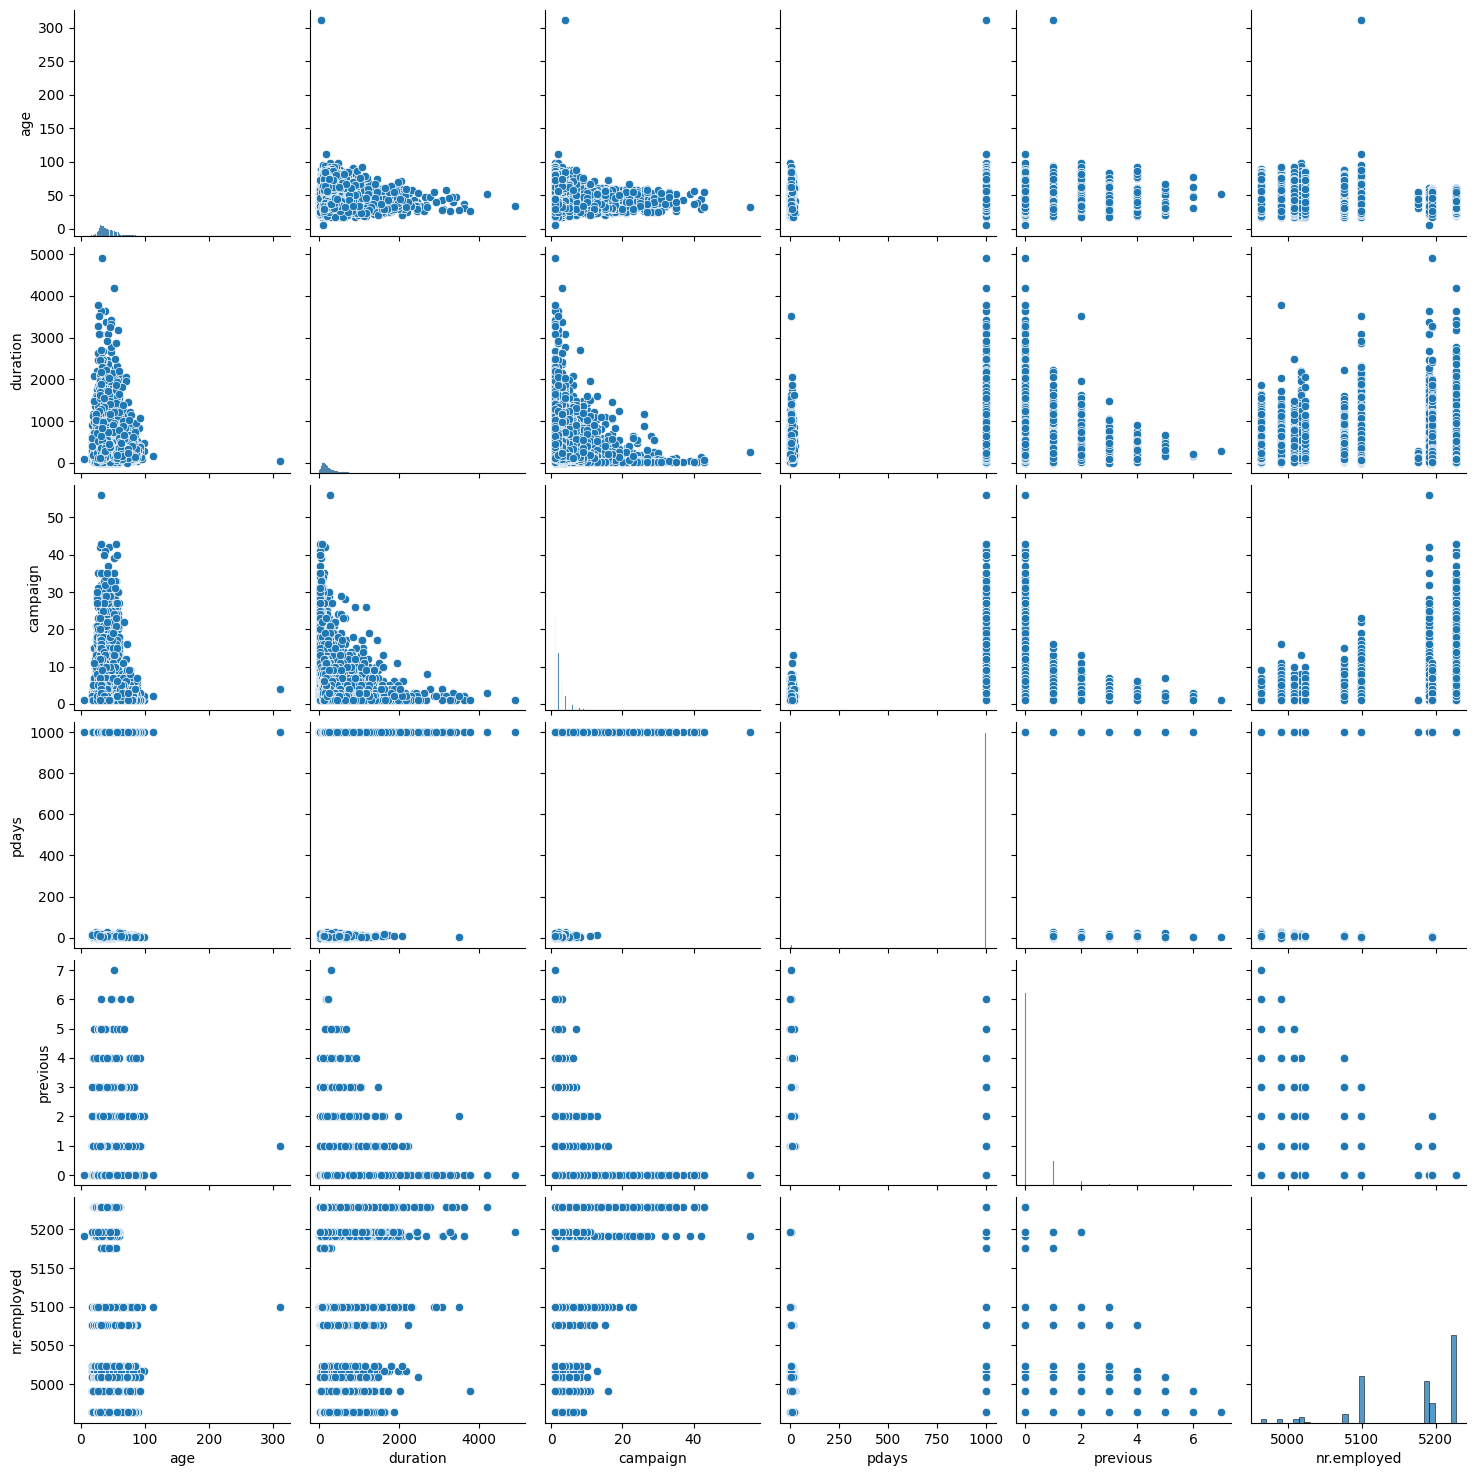

In [26]:
# Numeric variables
quant_col = sub_bank[['age', 'duration', 'campaign', 'pdays', 'previous', 'nr.employed']]

sns.pairplot(quant_col)

# Show the plot
plt.show()

**Discussion:**

With our most prominent quantitative variables, we can see correlations using numeric values.

Although the one point of the 311 year-old, likely a human error as we previously talked about, is skewing our data heavily for the age graphs, it makes sense for the remaining graphs that there will be a higher duration of campaigns if the person is of a relatively good response age. If they are too young or too old, they will not be able to comprehend what is actually going on. Age and the other variables seem to have relatively the same relationships as well.

With the other variables, there seems to be a general negative (r < 0) or nonexistent correlation (r ~ 0) except for that of number of employed individuals in our bank and the duration of the campaign. This positive relationship exists between the number of employees and the number of contacts performed in that campaign to a particular client. The latter certainly makes sense because if we have a greater number of employees, this gives more leeway to each employee to focus on marketing to a small cohort of individuals.

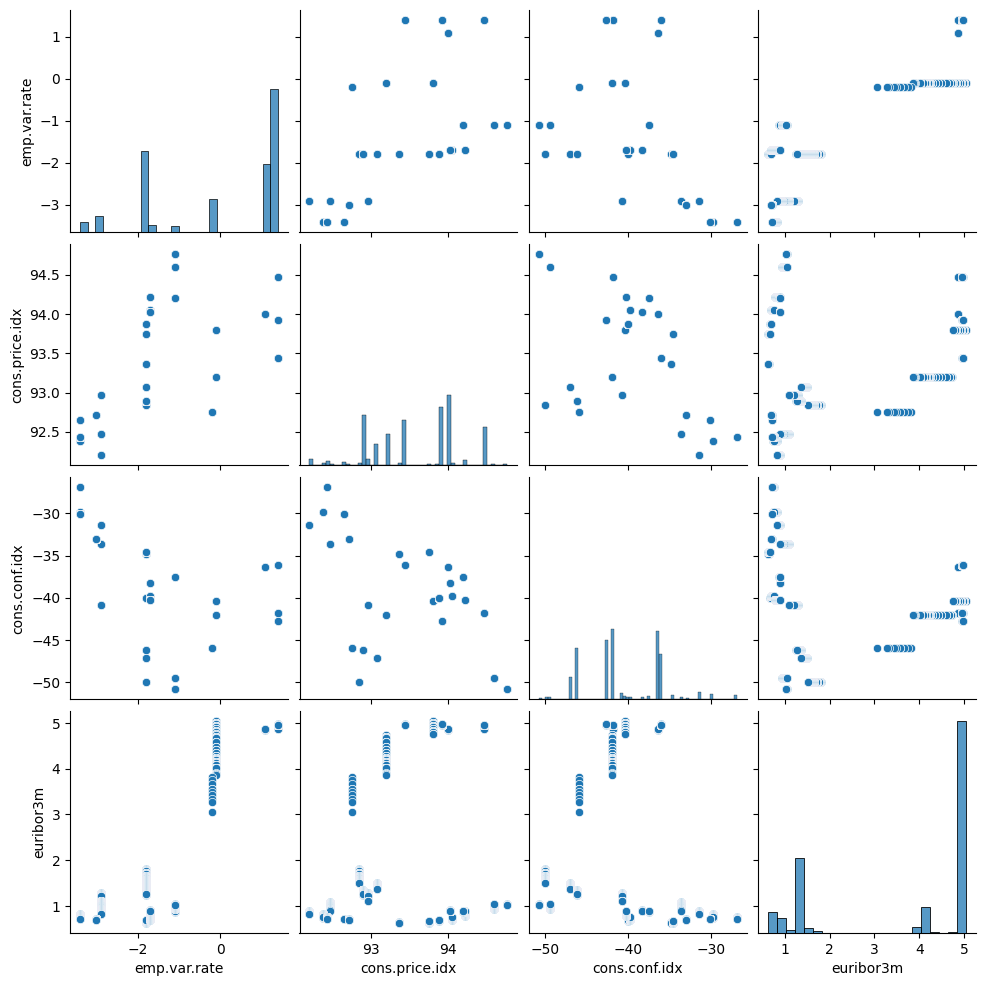

In [27]:
# Ratios
quant_rate_col = sub_bank[['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m']]

sns.pairplot(quant_rate_col)

# Show the plot
plt.show()

**Discussion:**

With our rates and indices, there is a lot more to look at here. In general, there are more overall positive or negative relationships between the variables. The employee turnover rate is directly proportional to the consumer price index but inversely proportional to the confidence index. This means consumers are paying average price for our services but likely not loving it. There is also a fair positive correlation etween the turnover rate and the European bank lending rate.

The consumer price and confidence indices are negatively correlated with each other, which makes sense based on our previous observations.

It is difficult to say whether the European bank lending rate has any real relationship to either of the indices.

Now, I want to see relationships between categorical and quantitative variables using models

In [28]:
sub_bank = sub_bank[sub_bank['age'] != 311] #remove the single outlier from the age dataset

***
## Modeling - KNN
***

In [32]:
# Import KNN
#!pip install scikit-learn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [33]:
# Convert into dummy variables
cleaned_one_hot = pd.get_dummies(sub_bank, columns=['job', 'marital', 'education', 'default', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y'])

cleaned_one_hot

,IDX,age,housing,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown,marital_divorced,...,loan_no,loan_unknown,loan_yes,contact_cellular,contact_telephone,month_apr,month_aug,month_dec,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success,y_no,y_yes
0,1,56,no,261,1,999,0,1.1,93.994,-36.4,4.857,5191.0,False,False,False,True,False,False,False,False,False,False,False,False,False,...,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,True,False,True,False
1,2,57,no,149,1,999,0,1.1,93.994,-36.4,4.857,5191.0,False,False,False,False,False,False,False,True,False,False,False,False,False,...,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,True,False,True,False
2,3,37,yes,226,1,999,0,1.1,93.994,-36.4,4.857,5191.0,False,False,False,False,False,False,False,True,False,False,False,False,False,...,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,True,False,True,False
3,4,40,no,151,1,999,0,1.1,93.994,-36.4,4.857,5191.0,True,False,False,False,False,False,False,False,False,False,False,False,False,...,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,True,False,True,False
4,5,56,no,307,1,999,0,1.1,93.994,-36.4,4.857,5191.0,False,False,False,False,False,False,False,True,False,False,False,False,False,...,False,False,True,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,41184,73,yes,334,1,999,0,-1.1,94.767,-50.8,1.028,4963.6,False,False,False,False,False,True,False,False,False,False,False,False,False,...,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,True,False,False,True
41184,41185,46,no,383,1,999,0,-1.1,94.767,-50.8,1.028,4963.6,False,True,False,False,False,False,False,False,False,False,False,False,False,...,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,True,False,True,False
41185,41186,56,yes,189,2,999,0,-1.1,94.767,-50.8,1.028,4963.6,False,False,False,False,False,True,False,False,False,False,False,False,False,...,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,True,False,True,False
41186,41187,44,no,442,1,999,0,-1.1,94.767,-50.8,1.028,4963.6,False,False,False,False,False,False,False,False,False,True,False,False,False,...,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,True,False,False,True


In [34]:
# Train-Test split
X = cleaned_one_hot.drop(columns=['y_no', 'y_yes', 'IDX', 'housing'])  # Drop response variables to leave only Predictors
y = cleaned_one_hot['y_yes']  # Response

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown,marital_divorced,marital_married,marital_single,...,default_unknown,default_yes,loan_no,loan_unknown,loan_yes,contact_cellular,contact_telephone,month_apr,month_aug,month_dec,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success
0,56,261,1,999,0,1.1,93.994,-36.4,4.857,5191.0,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,...,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,True,False
1,57,149,1,999,0,1.1,93.994,-36.4,4.857,5191.0,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,...,True,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,True,False
2,37,226,1,999,0,1.1,93.994,-36.4,4.857,5191.0,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,...,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,True,False
3,40,151,1,999,0,1.1,93.994,-36.4,4.857,5191.0,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,...,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,True,False
4,56,307,1,999,0,1.1,93.994,-36.4,4.857,5191.0,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,...,False,False,False,False,True,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,334,1,999,0,-1.1,94.767,-50.8,1.028,4963.6,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,...,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,True,False
41184,46,383,1,999,0,-1.1,94.767,-50.8,1.028,4963.6,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,...,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,True,False
41185,56,189,2,999,0,-1.1,94.767,-50.8,1.028,4963.6,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,...,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,True,False
41186,44,442,1,999,0,-1.1,94.767,-50.8,1.028,4963.6,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,...,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,True,False


In [35]:
knn10 = KNeighborsClassifier(n_neighbors=10)
knn10

,n_neighbors,10
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [36]:
import numpy as np
knn10.fit(X_train, y_train)

,n_neighbors,10
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [37]:
y_pred = knn10.predict(X_test)

In [38]:
accuracy = accuracy_score(y_test, y_pred)
print(f"KNN model accuracy (k = 10): {accuracy:.2f}")

KNN model accuracy (k = 10): 0.90


In [39]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [40]:
knn = KNeighborsClassifier()
param_grid = {'n_neighbors': np.arange(1, 31)}  # Try K values from 1 to 30
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_scaled, y_train)

,estimator,KNeighborsClassifier()
,param_grid,"{'n_neighbors': array([ 1, 2..., 28, 29, 30])}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,np.int64(30)


In [41]:
opt_k = grid_search.best_params_['n_neighbors']
best_score = grid_search.best_score_

print(f"Optimal K: {opt_k}")
print(f"Cross-validated Accuracy: {best_score:.4f}")

Optimal K: 30
Cross-validated Accuracy: 0.9003


In [42]:
# Evaluate on the test set using the optimal K
knn_best = KNeighborsClassifier(n_neighbors=opt_k)
knn_best.fit(X_train_scaled, y_train)
y_pred = knn_best.predict(X_test_scaled)

test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test Set Accuracy with K={opt_k}: {test_accuracy:.4f}")

# Confusion Matrix
knn_conf_matrix = confusion_matrix(y_test, y_pred)
print(f'Confusion Matrix:\n{knn_conf_matrix}')

# Classification Report
class_report = classification_report(y_test, y_pred)
print(f'Classification Report:\n{class_report}')

Test Set Accuracy with K=30: 0.8979
Confusion Matrix:
[[7198  114]
 [ 727  198]]
Classification Report:
              precision    recall  f1-score   support

       False       0.91      0.98      0.94      7312
        True       0.63      0.21      0.32       925

    accuracy                           0.90      8237
   macro avg       0.77      0.60      0.63      8237
weighted avg       0.88      0.90      0.87      8237

